# Notebook 05 — Model Training: RF vs. AHRF-v1 vs. AHRF-v2 (Ablation)

## Objective
Extend the locked AHRF-v1 baseline experiment into a three-way ablation comparing **Random Forest**, **AHRF-v1** (OOB-error adaptive weighting), and **AHRF-v2** (temporal-adaptive weighting, genuinely out-of-sample forward validation), under an identical leakage-safe protocol, for SOH, SOC, and RUL.

**This is a research comparison, not a foregone conclusion.** AHRF-v2 is not assumed to win. All three possible outcomes (RF best, AHRF-v1 best, AHRF-v2 best -- possibly differing by metric or by target) are valid, reportable results.

## Architecture
Uses only the existing `tune_random_forest()`, `tune_weighted_rf()` (`TimeSeriesSplit`-based), and `AdaptiveWeightedRF` (supporting `weighting_method="oob"`/`"temporal"`) from `src/`. No tuning logic and no tree-weighting formula is reimplemented here.

## AHRF-v2 Tuning Rule (read this before the results below)
`tune_weighted_rf()` optimizes AHRF-**v1** (OOB weighting) only -- it does not independently tune AHRF-v2. Independently tuning AHRF-v2 would require its own Optuna search, which this task does not authorize (and would cost additional compute for an ablation that already has a controlled variable to test). Instead, for a fair ablation, **AHRF-v2 reuses AHRF-v1's tuned hyperparameters exactly** (`n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`, `max_features`, `weight_power`) and only changes `weighting_method="oob"` to `weighting_method="temporal"`. This isolates the tree-aggregation mechanism as the single controlled difference between v1 and v2 -- exactly what an ablation study requires. It also means AHRF-v2's hyperparameters were optimized for OOB weighting, not for itself; if AHRF-v2 underperforms, this is a real, disclosed limitation of this specific experiment, not evidence against temporal weighting in general.

## Workflow Position
```
01 (LOCKED) -> 02 (LOCKED) -> 03 (LOCKED) -> 04 (LOCKED) -> [YOU ARE HERE] 05 Model Training (RF vs AHRF-v1 vs AHRF-v2)
-> 06 Model Comparison -> 07 Explainability (SHAP) -> 08 Decision Engine & Summary
```


## 1. Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
import time
import inspect
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from src.core.config import FEATURE_DATA, MODELS, RESULTS, EOL_SOH_THRESHOLD
from src.optimization.optuna_tuner import tune_random_forest, tune_weighted_rf
from src.hybrid_model.weighted_random_forest import AdaptiveWeightedRF

plt.rcParams["figure.figsize"] = (10, 5)
RANDOM_STATE = 42
N_TEMPORAL_SPLITS = 3
PRIMARY_METRIC = "MAE"  # stated explicitly per task requirement: MAE is the primary
                         # comparison metric (directly interpretable in target units);
                         # RMSE and R2 are secondary.


In [3]:
df = pd.read_csv(FEATURE_DATA / "full_labeled_dataset.csv")
df = df.sort_values("cycle_index").reset_index(drop=True)
print("Loaded dataset:", df.shape)


Loaded dataset: (168, 85)


## 2. Feature Definition — Leakage-Safe (Unchanged from the Locked AHRF-v1 Baseline)


In [4]:
NON_FEATURE_COLUMNS = [
    "SOC", "SOH (%)", "RUL", "Capacity",
    "File", "cycle_index", "Experiment", "battery_id", "filename",
    "type", "start_time", "test_id", "uid", "Re", "Rct", "ambient_temperature",
]

MODEL_CANDIDATE_FEATURE_COLUMNS = [c for c in df.columns if c not in NON_FEATURE_COLUMNS]

print(f"Total columns in dataset: {df.shape[1]}")
print(f"Excluded columns present: {[c for c in NON_FEATURE_COLUMNS if c in df.columns]}")
print(f"Model candidate feature count: {len(MODEL_CANDIDATE_FEATURE_COLUMNS)}")


Total columns in dataset: 85
Excluded columns present: ['SOC', 'SOH (%)', 'RUL', 'Capacity', 'File', 'cycle_index', 'Experiment', 'battery_id']
Model candidate feature count: 77


In [5]:
def build_X_y(source_df, target_col, feature_cols=MODEL_CANDIDATE_FEATURE_COLUMNS):
    """Builds X/y for one target, with hard assertions that no target or
    auxiliary column leaked into X. Unchanged from the locked baseline."""
    X = source_df[feature_cols].copy()
    y = source_df[target_col].copy()

    assert target_col not in X.columns, f"LEAKAGE: {target_col} present in X"
    assert "SOC" not in X.columns, "LEAKAGE: SOC present in X"
    assert "SOH (%)" not in X.columns, "LEAKAGE: SOH (%) present in X"
    assert "RUL" not in X.columns, "LEAKAGE: RUL present in X"
    assert "Capacity" not in X.columns, "LEAKAGE: Capacity present in X"

    return X, y


def chronological_split(source_df, cycle_col="cycle_index", train_frac=0.8):
    """Chronological 80/20 split, no shuffling. Unchanged from the locked baseline."""
    sorted_df = source_df.sort_values(cycle_col).reset_index(drop=True)
    n = len(sorted_df)
    split = int(n * train_frac)
    train_df = sorted_df.iloc[:split].copy()
    test_df = sorted_df.iloc[split:].copy()

    assert train_df[cycle_col].max() < test_df[cycle_col].min(), (
        "CHRONOLOGY VIOLATED: train cycles overlap with or exceed test cycles."
    )
    assert len(train_df) + len(test_df) == len(sorted_df), (
        "ROW COUNT MISMATCH: train + test does not equal total rows."
    )

    return train_df, test_df


def impute_train_test(X_train, X_test, label=""):
    """Fit SimpleImputer(strategy='median') on X_train ONLY. Unchanged from
    the locked baseline."""
    nan_in_train = int(X_train.isna().sum().sum())
    nan_in_test = int(X_test.isna().sum().sum())
    affected_features = X_train.columns[X_train.isna().any()].tolist()
    affected_rows_train = int(X_train.isna().any(axis=1).sum())
    affected_rows_test = int(X_test.isna().any(axis=1).sum())

    print(f"  [{label}] NaN count in X_train: {nan_in_train}")
    print(f"  [{label}] NaN count in X_test:  {nan_in_test}")
    print(f"  [{label}] Affected features: {affected_features}")
    print(f"  [{label}] Affected rows -- train: {affected_rows_train}, test: {affected_rows_test}")

    imputer = SimpleImputer(strategy="median")
    imputer.fit(X_train)  # fit ONLY on training data

    X_train_processed = pd.DataFrame(imputer.transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test_processed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

    assert X_train_processed.isna().sum().sum() == 0, "NaNs remain in X_train after imputation"
    assert X_test_processed.isna().sum().sum() == 0, "NaNs remain in X_test after imputation"
    assert np.isfinite(X_train_processed.to_numpy()).all(), "Non-finite values in X_train after imputation"
    assert np.isfinite(X_test_processed.to_numpy()).all(), "Non-finite values in X_test after imputation"

    print(f"  [{label}] PASS: zero NaN, zero inf in both X_train_processed and X_test_processed.")

    return X_train_processed, X_test_processed, imputer


def evaluate_model(model, X_test, y_test):
    start = time.perf_counter()
    y_pred = model.predict(X_test)
    prediction_time = time.perf_counter() - start
    assert np.isfinite(y_pred).all(), "Predictions contain non-finite values"
    return {
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
        "prediction_time": prediction_time,
        "y_pred": y_pred,
    }


## 3. AHRF Weight Reporting (v1 = OOB, v2 = Temporal)

Two separate reporting functions, since AHRF-v1 exposes `tree_oob_errors_` and AHRF-v2 exposes `tree_temporal_errors_`/`temporal_fold_scores_` -- different diagnostic attributes for different weighting mechanisms.


In [6]:
def report_ahrf_v1_weights(ahrf_model, label):
    """AHRF-v1 (OOB) tree-weight report."""
    weights = ahrf_model.tree_weights_
    errors = ahrf_model.tree_oob_errors_
    weight_sum = weights.sum()
    assert np.isclose(weight_sum, 1.0, atol=1e-6), f"AHRF-v1 weights do not sum to 1 for {label}: {weight_sum}"

    print(f"AHRF-v1 (OOB) Tree Weight Report -- {label}")
    print(f"  weighting_method: {ahrf_model.weighting_method}")
    print(f"  Number of trees: {len(weights)}")
    print(f"  weight_power: {ahrf_model.weight_power:.4f}")
    print(f"  Min weight: {weights.min():.6f}   Max weight: {weights.max():.6f}   Mean weight: {weights.mean():.6f}")
    print(f"  Sum of weights (should be ~1): {weight_sum:.8f}  [PASS]")
    top10_idx = np.argsort(weights)[::-1][:10]
    print("  Top 10 tree weights and their OOB errors:")
    for rank, idx in enumerate(top10_idx, 1):
        print(f"    #{rank:2d}  tree {idx:4d}   weight={weights[idx]:.6f}   OOB_MAE={errors[idx]:.4f}")


def report_ahrf_v2_weights(ahrf_model, label):
    """AHRF-v2 (temporal) tree-weight report."""
    weights = ahrf_model.tree_weights_
    errors = ahrf_model.tree_temporal_errors_
    fold_scores = ahrf_model.temporal_fold_scores_
    weight_sum = weights.sum()
    assert np.isclose(weight_sum, 1.0, atol=1e-6), f"AHRF-v2 weights do not sum to 1 for {label}: {weight_sum}"

    print(f"AHRF-v2 (temporal) Tree Weight Report -- {label}")
    print(f"  weighting_method: {ahrf_model.weighting_method}")
    print(f"  n_temporal_splits: {ahrf_model.n_temporal_splits}")
    print(f"  Number of trees: {len(weights)}")
    print(f"  weight_power: {ahrf_model.weight_power:.4f}")
    print(f"  Min weight: {weights.min():.6f}   Max weight: {weights.max():.6f}   Mean weight: {weights.mean():.6f}")
    print(f"  Sum of weights (should be ~1): {weight_sum:.8f}  [PASS]")
    top10_idx = np.argsort(weights)[::-1][:10]
    print("  Top 10 tree weights and their temporal tree-slot errors:")
    for rank, idx in enumerate(top10_idx, 1):
        print(f"    #{rank:2d}  tree {idx:4d}   weight={weights[idx]:.6f}   temporal_MAE={errors[idx]:.4f}")
    if fold_scores is not None:
        print(f"  Per-fold mean validation MAE (temporal_fold_scores_): "
              f"{np.array2string(fold_scores, precision=4)}")
    print("  Temporal reliability of deterministic tree slots was estimated using independently")
    print("  trained forward-validation forests, then transferred to the final full-data forest")
    print("  (see src/hybrid_model/weighted_random_forest.py module docstring).")


## 4. Experiment Runner — RF, AHRF-v1, AHRF-v2

All three models see **identical source rows, chronological split, candidate features, imputation, and `random_state`**. AHRF-v2 uses AHRF-v1's tuned hyperparameters (see the tuning rule above) with only `weighting_method` and `n_temporal_splits` changed.


In [7]:
def run_experiment(target_name, target_col, source_df, n_trials, cv=3, random_state=RANDOM_STATE):
    print("=" * 70)
    print(f"EXPERIMENT: {target_name}  (target column: '{target_col}')")
    print("=" * 70)

    train_df, test_df = chronological_split(source_df)
    print(f"Train rows: {len(train_df)}  Test rows: {len(test_df)}  "
          f"(train cycles {int(train_df['cycle_index'].min())}-{int(train_df['cycle_index'].max())}, "
          f"test cycles {int(test_df['cycle_index'].min())}-{int(test_df['cycle_index'].max())})")

    X_train, y_train = build_X_y(train_df, target_col)
    X_test, y_test = build_X_y(test_df, target_col)
    print("PASS: no target/auxiliary leakage in X (checked via assertions in build_X_y).")

    print()
    print("Imputation (median, fit on X_train ONLY):")
    X_train_p, X_test_p, imputer = impute_train_test(X_train, X_test, label=target_name)

    # ---- Model 1: Random Forest ----
    print()
    print(f"Tuning Random Forest -- TimeSeriesSplit(n_splits={cv}), n_trials={n_trials}")
    best_rf_params, study_rf = tune_random_forest(X_train_p, y_train, n_trials=n_trials, cv=cv, random_state=random_state)
    print(f"  Best validation MAE: {study_rf.best_value:.4f}  |  trials: {len(study_rf.trials)}  |  strategy: TimeSeriesSplit(n_splits={cv})")

    t0 = time.perf_counter()
    rf_model = RandomForestRegressor(**best_rf_params, random_state=random_state, n_jobs=-1)
    rf_model.fit(X_train_p, y_train)
    rf_training_time = time.perf_counter() - t0
    rf_results = evaluate_model(rf_model, X_test_p, y_test)
    rf_results["training_time"] = rf_training_time

    # ---- Model 2: AHRF-v1 (OOB) ----
    print()
    print(f"Tuning AHRF-v1 (OOB) -- TimeSeriesSplit(n_splits={cv}), n_trials={n_trials}")
    best_ahrf_params, study_ahrf = tune_weighted_rf(X_train_p, y_train, n_trials=n_trials, cv=cv, random_state=random_state)
    print(f"  Best validation MAE: {study_ahrf.best_value:.4f}  |  trials: {len(study_ahrf.trials)}  |  strategy: TimeSeriesSplit(n_splits={cv})")

    t0 = time.perf_counter()
    ahrf_v1_model = AdaptiveWeightedRF(**best_ahrf_params, random_state=random_state, weighting_method="oob")
    ahrf_v1_model.fit(X_train_p, y_train)
    ahrf_v1_training_time = time.perf_counter() - t0
    ahrf_v1_results = evaluate_model(ahrf_v1_model, X_test_p, y_test)
    ahrf_v1_results["training_time"] = ahrf_v1_training_time

    # ---- Model 3: AHRF-v2 (temporal) -- REUSES AHRF-v1's tuned hyperparameters ----
    print()
    print(f"AHRF-v2 (temporal): reusing AHRF-v1's tuned hyperparameters (NOT independently")
    print(f"tuned -- see notebook documentation above), weighting_method='temporal', n_temporal_splits={N_TEMPORAL_SPLITS}")
    t0 = time.perf_counter()
    ahrf_v2_model = AdaptiveWeightedRF(**best_ahrf_params, random_state=random_state,
                                        weighting_method="temporal", n_temporal_splits=N_TEMPORAL_SPLITS)
    ahrf_v2_model.fit(X_train_p, y_train)
    ahrf_v2_training_time = time.perf_counter() - t0
    ahrf_v2_results = evaluate_model(ahrf_v2_model, X_test_p, y_test)
    ahrf_v2_results["training_time"] = ahrf_v2_training_time

    print()
    print("[FINAL TEST SET RESULTS -- untouched, never used in tuning/imputation/weighting]")
    print(f"  Random Forest : MAE={rf_results['MAE']:.4f}  RMSE={rf_results['RMSE']:.4f}  "
          f"R2={rf_results['R2']:.4f}  train={rf_training_time:.3f}s  pred={rf_results['prediction_time']:.4f}s")
    print(f"  AHRF-v1 (OOB) : MAE={ahrf_v1_results['MAE']:.4f}  RMSE={ahrf_v1_results['RMSE']:.4f}  "
          f"R2={ahrf_v1_results['R2']:.4f}  train={ahrf_v1_training_time:.3f}s  pred={ahrf_v1_results['prediction_time']:.4f}s")
    print(f"  AHRF-v2 (temp): MAE={ahrf_v2_results['MAE']:.4f}  RMSE={ahrf_v2_results['RMSE']:.4f}  "
          f"R2={ahrf_v2_results['R2']:.4f}  train={ahrf_v2_training_time:.3f}s  pred={ahrf_v2_results['prediction_time']:.4f}s")

    all_results = {"Random Forest": rf_results, "AHRF-v1": ahrf_v1_results, "AHRF-v2": ahrf_v2_results}
    winner = min(all_results, key=lambda k: all_results[k][PRIMARY_METRIC])
    print(f"\n  Winner by {PRIMARY_METRIC} (primary metric): {winner}")

    v2_vs_v1_mae_improvement = ahrf_v1_results["MAE"] - ahrf_v2_results["MAE"]
    v2_vs_v1_rmse_improvement = ahrf_v1_results["RMSE"] - ahrf_v2_results["RMSE"]
    v2_vs_v1_r2_diff = ahrf_v2_results["R2"] - ahrf_v1_results["R2"]
    hypothesis_supported = winner == "AHRF-v2"
    print(f"  AHRF-v2 MAE improvement over AHRF-v1: {v2_vs_v1_mae_improvement:+.4f}")
    print(f"  AHRF-v2 RMSE improvement over AHRF-v1: {v2_vs_v1_rmse_improvement:+.4f}")
    print(f"  AHRF-v2 R2 difference vs AHRF-v1: {v2_vs_v1_r2_diff:+.4f}")
    print(f"  Research hypothesis supported for {target_name}: {'YES' if hypothesis_supported else 'NO'}")
    if not hypothesis_supported:
        print(f"  (AHRF-v2 did not beat both RF and AHRF-v1 on {PRIMARY_METRIC} for {target_name} -- "
              "reporting this honestly, not adjusting the experiment.)")

    return {
        "target_name": target_name, "target_col": target_col,
        "train_df": train_df, "test_df": test_df,
        "X_train": X_train_p, "X_test": X_test_p, "y_train": y_train, "y_test": y_test,
        "rf_model": rf_model, "ahrf_v1_model": ahrf_v1_model, "ahrf_v2_model": ahrf_v2_model,
        "rf_results": rf_results, "ahrf_v1_results": ahrf_v1_results, "ahrf_v2_results": ahrf_v2_results,
        "best_rf_params": best_rf_params, "best_ahrf_params": best_ahrf_params,
        "imputer": imputer, "winner": winner,
        "v2_vs_v1_mae_improvement": v2_vs_v1_mae_improvement,
        "v2_vs_v1_rmse_improvement": v2_vs_v1_rmse_improvement,
        "v2_vs_v1_r2_diff": v2_vs_v1_r2_diff,
        "hypothesis_supported": hypothesis_supported,
    }


## 5. SOH Experiment (all 168 cycles, chronological 134/34 split)


In [8]:
soh_result = run_experiment("SOH", "SOH (%)", df, n_trials=15, cv=3)


EXPERIMENT: SOH  (target column: 'SOH (%)')
Train rows: 134  Test rows: 34  (train cycles 1-134, test cycles 135-168)
PASS: no target/auxiliary leakage in X (checked via assertions in build_X_y).

Imputation (median, fit on X_train ONLY):
  [SOH] NaN count in X_train: 78
  [SOH] NaN count in X_test:  0
  [SOH] Affected features: ['Re_nearest', 'Rct_nearest', 'Re_trend', 'Rct_trend']
  [SOH] Affected rows -- train: 20, test: 0
  [SOH] PASS: zero NaN, zero inf in both X_train_processed and X_test_processed.

Tuning Random Forest -- TimeSeriesSplit(n_splits=3), n_trials=15


  0%|          | 0/15 [00:00<?, ?it/s]

Best MAE (cross-validated): 4.20226
Best parameters: {'n_estimators': 350, 'max_depth': 21, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
  Best validation MAE: 4.2023  |  trials: 15  |  strategy: TimeSeriesSplit(n_splits=3)

Tuning AHRF-v1 (OOB) -- TimeSeriesSplit(n_splits=3), n_trials=15


  0%|          | 0/15 [00:00<?, ?it/s]

Best MAE (cross-validated): 4.51615
Best parameters: {'n_estimators': 400, 'max_depth': 25, 'min_samples_split': 7, 'min_samples_leaf': 4, 'max_features': None, 'weight_power': 3.9666279350768363}
  Best validation MAE: 4.5161  |  trials: 15  |  strategy: TimeSeriesSplit(n_splits=3)

AHRF-v2 (temporal): reusing AHRF-v1's tuned hyperparameters (NOT independently
tuned -- see notebook documentation above), weighting_method='temporal', n_temporal_splits=3

[FINAL TEST SET RESULTS -- untouched, never used in tuning/imputation/weighting]
  Random Forest : MAE=2.3736  RMSE=2.6044  R2=-4.4994  train=0.267s  pred=0.0522s
  AHRF-v1 (OOB) : MAE=2.7287  RMSE=2.9377  R2=-5.9970  train=0.675s  pred=0.0238s
  AHRF-v2 (temp): MAE=2.7440  RMSE=2.9495  R2=-6.0536  train=1.532s  pred=0.0239s

  Winner by MAE (primary metric): Random Forest
  AHRF-v2 MAE improvement over AHRF-v1: -0.0153
  AHRF-v2 RMSE improvement over AHRF-v1: -0.0118
  AHRF-v2 R2 difference vs AHRF-v1: -0.0565
  Research hypothesis sup

In [9]:
report_ahrf_v1_weights(soh_result["ahrf_v1_model"], "SOH")
print()
report_ahrf_v2_weights(soh_result["ahrf_v2_model"], "SOH")


AHRF-v1 (OOB) Tree Weight Report -- SOH
  weighting_method: oob
  Number of trees: 400
  weight_power: 3.9666
  Min weight: 0.000069   Max weight: 0.009574   Mean weight: 0.002500
  Sum of weights (should be ~1): 1.00000000  [PASS]
  Top 10 tree weights and their OOB errors:
    # 1  tree  295   weight=0.009574   OOB_MAE=0.4332
    # 2  tree  117   weight=0.008041   OOB_MAE=0.4527
    # 3  tree  188   weight=0.008038   OOB_MAE=0.4527
    # 4  tree  226   weight=0.007809   OOB_MAE=0.4560
    # 5  tree   51   weight=0.007658   OOB_MAE=0.4583
    # 6  tree  312   weight=0.007558   OOB_MAE=0.4598
    # 7  tree  140   weight=0.007485   OOB_MAE=0.4609
    # 8  tree  256   weight=0.007407   OOB_MAE=0.4621
    # 9  tree  338   weight=0.007318   OOB_MAE=0.4636
    #10  tree  118   weight=0.007196   OOB_MAE=0.4655

AHRF-v2 (temporal) Tree Weight Report -- SOH
  weighting_method: temporal
  n_temporal_splits: 3
  Number of trees: 400
  weight_power: 3.9666
  Min weight: 0.001028   Max weight: 0.0

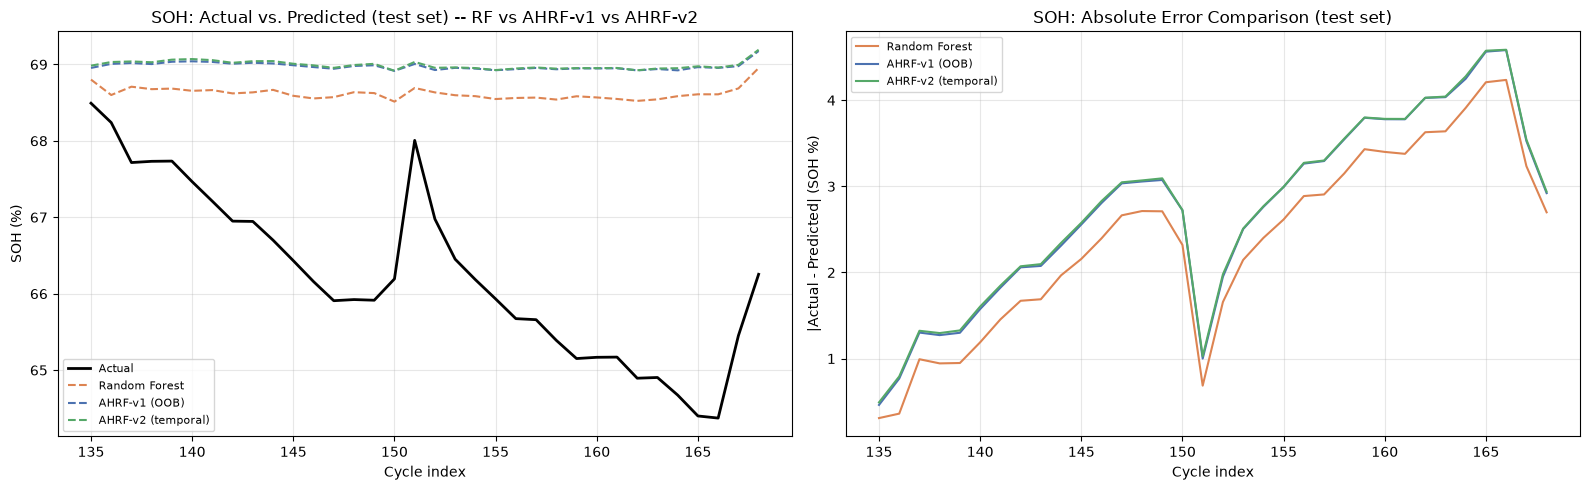

In [10]:
test_cycles = soh_result["test_df"]["cycle_index"].values

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(test_cycles, soh_result["y_test"].values, label="Actual", color="black", linewidth=2)
axes[0].plot(test_cycles, soh_result["rf_results"]["y_pred"], label="Random Forest", linestyle="--", color="#DD8452")
axes[0].plot(test_cycles, soh_result["ahrf_v1_results"]["y_pred"], label="AHRF-v1 (OOB)", linestyle="--", color="#4C72B0")
axes[0].plot(test_cycles, soh_result["ahrf_v2_results"]["y_pred"], label="AHRF-v2 (temporal)", linestyle="--", color="#55A868")
axes[0].set_title("SOH: Actual vs. Predicted (test set) -- RF vs AHRF-v1 vs AHRF-v2")
axes[0].set_xlabel("Cycle index"); axes[0].set_ylabel("SOH (%)")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

abs_err_rf = np.abs(soh_result["y_test"].values - soh_result["rf_results"]["y_pred"])
abs_err_v1 = np.abs(soh_result["y_test"].values - soh_result["ahrf_v1_results"]["y_pred"])
abs_err_v2 = np.abs(soh_result["y_test"].values - soh_result["ahrf_v2_results"]["y_pred"])
axes[1].plot(test_cycles, abs_err_rf, label="Random Forest", color="#DD8452")
axes[1].plot(test_cycles, abs_err_v1, label="AHRF-v1 (OOB)", color="#4C72B0")
axes[1].plot(test_cycles, abs_err_v2, label="AHRF-v2 (temporal)", color="#55A868")
axes[1].set_title("SOH: Absolute Error Comparison (test set)")
axes[1].set_xlabel("Cycle index"); axes[1].set_ylabel("|Actual - Predicted| (SOH %)")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### SOH Observation
See the printed test-set metrics, winner, and hypothesis result above (Section 5) -- curves and error lines above are plotted directly from the actual predictions, not adjusted to visually favor any model.


## 6. SOC Experiment (same methodology; voltage-based proxy label)

**Reminder:** SOC is a voltage-based proxy, not a direct Coulomb-counted ground truth -- results below measure how well each model reconstructs the proxy, not validated physical SOC estimation accuracy.


In [11]:
soc_result = run_experiment("SOC", "SOC", df, n_trials=12, cv=3)


EXPERIMENT: SOC  (target column: 'SOC')
Train rows: 134  Test rows: 34  (train cycles 1-134, test cycles 135-168)
PASS: no target/auxiliary leakage in X (checked via assertions in build_X_y).

Imputation (median, fit on X_train ONLY):
  [SOC] NaN count in X_train: 78
  [SOC] NaN count in X_test:  0
  [SOC] Affected features: ['Re_nearest', 'Rct_nearest', 'Re_trend', 'Rct_trend']
  [SOC] Affected rows -- train: 20, test: 0
  [SOC] PASS: zero NaN, zero inf in both X_train_processed and X_test_processed.

Tuning Random Forest -- TimeSeriesSplit(n_splits=3), n_trials=12


  0%|          | 0/12 [00:00<?, ?it/s]

Best MAE (cross-validated): 12.74229
Best parameters: {'n_estimators': 250, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}
  Best validation MAE: 12.7423  |  trials: 12  |  strategy: TimeSeriesSplit(n_splits=3)

Tuning AHRF-v1 (OOB) -- TimeSeriesSplit(n_splits=3), n_trials=12


  0%|          | 0/12 [00:00<?, ?it/s]

Best MAE (cross-validated): 12.58829
Best parameters: {'n_estimators': 450, 'max_depth': 23, 'min_samples_split': 9, 'min_samples_leaf': 3, 'max_features': None, 'weight_power': 2.071759675684855}
  Best validation MAE: 12.5883  |  trials: 12  |  strategy: TimeSeriesSplit(n_splits=3)

AHRF-v2 (temporal): reusing AHRF-v1's tuned hyperparameters (NOT independently
tuned -- see notebook documentation above), weighting_method='temporal', n_temporal_splits=3

[FINAL TEST SET RESULTS -- untouched, never used in tuning/imputation/weighting]
  Random Forest : MAE=7.9570  RMSE=8.9131  R2=-2.4908  train=0.193s  pred=0.0292s
  AHRF-v1 (OOB) : MAE=10.7039  RMSE=11.5858  R2=-4.8982  train=0.546s  pred=0.0244s
  AHRF-v2 (temp): MAE=10.8179  RMSE=11.6915  R2=-5.0064  train=1.687s  pred=0.0262s

  Winner by MAE (primary metric): Random Forest
  AHRF-v2 MAE improvement over AHRF-v1: -0.1140
  AHRF-v2 RMSE improvement over AHRF-v1: -0.1058
  AHRF-v2 R2 difference vs AHRF-v1: -0.1082
  Research hypothesi

In [12]:
report_ahrf_v1_weights(soc_result["ahrf_v1_model"], "SOC")
print()
report_ahrf_v2_weights(soc_result["ahrf_v2_model"], "SOC")


AHRF-v1 (OOB) Tree Weight Report -- SOC
  weighting_method: oob
  Number of trees: 450
  weight_power: 2.0718
  Min weight: 0.000841   Max weight: 0.006148   Mean weight: 0.002222
  Sum of weights (should be ~1): 1.00000000  [PASS]
  Top 10 tree weights and their OOB errors:
    # 1  tree   26   weight=0.006148   OOB_MAE=1.3630
    # 2  tree   96   weight=0.005761   OOB_MAE=1.4064
    # 3  tree  264   weight=0.005442   OOB_MAE=1.4456
    # 4  tree  286   weight=0.004860   OOB_MAE=1.5267
    # 5  tree   23   weight=0.004835   OOB_MAE=1.5305
    # 6  tree    0   weight=0.004511   OOB_MAE=1.5826
    # 7  tree  161   weight=0.004155   OOB_MAE=1.6467
    # 8  tree   63   weight=0.004147   OOB_MAE=1.6483
    # 9  tree  279   weight=0.004043   OOB_MAE=1.6686
    #10  tree  244   weight=0.004032   OOB_MAE=1.6708

AHRF-v2 (temporal) Tree Weight Report -- SOC
  weighting_method: temporal
  n_temporal_splits: 3
  Number of trees: 450
  weight_power: 2.0718
  Min weight: 0.001294   Max weight: 0.0

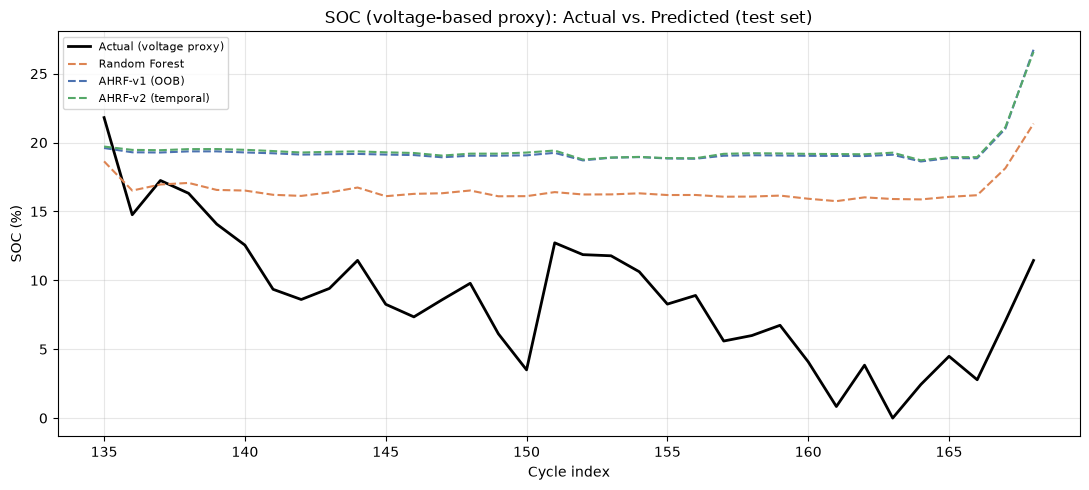

In [13]:
test_cycles = soc_result["test_df"]["cycle_index"].values
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(test_cycles, soc_result["y_test"].values, label="Actual (voltage proxy)", color="black", linewidth=2)
ax.plot(test_cycles, soc_result["rf_results"]["y_pred"], label="Random Forest", linestyle="--", color="#DD8452")
ax.plot(test_cycles, soc_result["ahrf_v1_results"]["y_pred"], label="AHRF-v1 (OOB)", linestyle="--", color="#4C72B0")
ax.plot(test_cycles, soc_result["ahrf_v2_results"]["y_pred"], label="AHRF-v2 (temporal)", linestyle="--", color="#55A868")
ax.set_title("SOC (voltage-based proxy): Actual vs. Predicted (test set)")
ax.set_xlabel("Cycle index"); ax.set_ylabel("SOC (%)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### SOC Observation
See the printed test-set metrics, winner, and hypothesis result above (Section 6).


## 7. RUL Experiment (pre-EOL trajectory only)

Post-EOL cycles (RUL trivially 0) are excluded, using the configured `EOL_SOH_THRESHOLD` -- unchanged from the locked baseline's methodology.


In [14]:
first_eol_cycle = int(df[df["SOH (%)"] <= EOL_SOH_THRESHOLD].sort_values("cycle_index")["cycle_index"].iloc[0])
print(f"Configured EOL_SOH_THRESHOLD: {EOL_SOH_THRESHOLD}%   First cycle at/below threshold: {first_eol_cycle}")

rul_source_df = df[df["cycle_index"] <= first_eol_cycle].copy()
print(f"RUL modeling restricted to cycle_index 1-{first_eol_cycle}: {len(rul_source_df)} rows "
      f"(excluded {len(df) - len(rul_source_df)} post-EOL, degenerate RUL=0 rows)")


Configured EOL_SOH_THRESHOLD: 80.0%   First cycle at/below threshold: 75
RUL modeling restricted to cycle_index 1-75: 75 rows (excluded 93 post-EOL, degenerate RUL=0 rows)


In [15]:
rul_result = run_experiment("RUL", "RUL", rul_source_df, n_trials=12, cv=3)

test_rul_std = rul_result["y_test"].std()
test_rul_nunique = rul_result["y_test"].nunique()
assert test_rul_std > 0, "VALIDATION FAILED: RUL test target is constant (degenerate)."
assert test_rul_nunique > 1, "VALIDATION FAILED: RUL test target has only one unique value."
print(f"\nPASS: RUL test target is non-degenerate (std={test_rul_std:.4f}, {test_rul_nunique} unique values).")


EXPERIMENT: RUL  (target column: 'RUL')
Train rows: 60  Test rows: 15  (train cycles 1-60, test cycles 61-75)
PASS: no target/auxiliary leakage in X (checked via assertions in build_X_y).

Imputation (median, fit on X_train ONLY):
  [RUL] NaN count in X_train: 78
  [RUL] NaN count in X_test:  0
  [RUL] Affected features: ['Re_nearest', 'Rct_nearest', 'Re_trend', 'Rct_trend']
  [RUL] Affected rows -- train: 20, test: 0
  [RUL] PASS: zero NaN, zero inf in both X_train_processed and X_test_processed.

Tuning Random Forest -- TimeSeriesSplit(n_splits=3), n_trials=12


  0%|          | 0/12 [00:00<?, ?it/s]

Best MAE (cross-validated): 15.95663
Best parameters: {'n_estimators': 100, 'max_depth': 22, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2'}
  Best validation MAE: 15.9566  |  trials: 12  |  strategy: TimeSeriesSplit(n_splits=3)

Tuning AHRF-v1 (OOB) -- TimeSeriesSplit(n_splits=3), n_trials=12


  0%|          | 0/12 [00:00<?, ?it/s]

Best MAE (cross-validated): 15.74954
Best parameters: {'n_estimators': 350, 'max_depth': 9, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'log2', 'weight_power': 0.33050199616107934}
  Best validation MAE: 15.7495  |  trials: 12  |  strategy: TimeSeriesSplit(n_splits=3)

AHRF-v2 (temporal): reusing AHRF-v1's tuned hyperparameters (NOT independently
tuned -- see notebook documentation above), weighting_method='temporal', n_temporal_splits=3

[FINAL TEST SET RESULTS -- untouched, never used in tuning/imputation/weighting]
  Random Forest : MAE=13.9627  RMSE=14.7589  R2=-10.6692  train=0.106s  pred=0.0202s
  AHRF-v1 (OOB) : MAE=13.3549  RMSE=14.1604  R2=-9.7420  train=0.401s  pred=0.0179s
  AHRF-v2 (temp): MAE=13.5654  RMSE=14.3627  R2=-10.0510  train=1.238s  pred=0.0209s

  Winner by MAE (primary metric): AHRF-v1
  AHRF-v2 MAE improvement over AHRF-v1: -0.2104
  AHRF-v2 RMSE improvement over AHRF-v1: -0.2023
  AHRF-v2 R2 difference vs AHRF-v1: -0.3091
  Research hypothes

In [16]:
report_ahrf_v1_weights(rul_result["ahrf_v1_model"], "RUL")
print()
report_ahrf_v2_weights(rul_result["ahrf_v2_model"], "RUL")


AHRF-v1 (OOB) Tree Weight Report -- RUL
  weighting_method: oob
  Number of trees: 350
  weight_power: 0.3305
  Min weight: 0.002120   Max weight: 0.003820   Mean weight: 0.002857
  Sum of weights (should be ~1): 1.00000000  [PASS]
  Top 10 tree weights and their OOB errors:
    # 1  tree  134   weight=0.003820   OOB_MAE=1.6460
    # 2  tree   62   weight=0.003591   OOB_MAE=1.9841
    # 3  tree  159   weight=0.003526   OOB_MAE=2.0965
    # 4  tree  124   weight=0.003497   OOB_MAE=2.1500
    # 5  tree  154   weight=0.003486   OOB_MAE=2.1711
    # 6  tree   31   weight=0.003467   OOB_MAE=2.2067
    # 7  tree  195   weight=0.003427   OOB_MAE=2.2867
    # 8  tree    9   weight=0.003426   OOB_MAE=2.2885
    # 9  tree  277   weight=0.003416   OOB_MAE=2.3080
    #10  tree  185   weight=0.003415   OOB_MAE=2.3106

AHRF-v2 (temporal) Tree Weight Report -- RUL
  weighting_method: temporal
  n_temporal_splits: 3
  Number of trees: 350
  weight_power: 0.3305
  Min weight: 0.002446   Max weight: 0.0

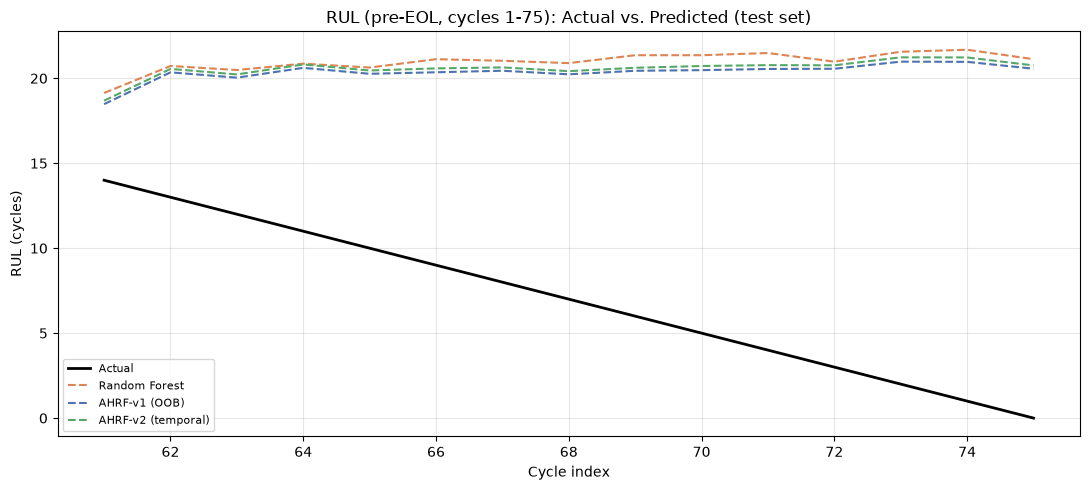

In [17]:
test_cycles = rul_result["test_df"]["cycle_index"].values
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(test_cycles, rul_result["y_test"].values, label="Actual", color="black", linewidth=2)
ax.plot(test_cycles, rul_result["rf_results"]["y_pred"], label="Random Forest", linestyle="--", color="#DD8452")
ax.plot(test_cycles, rul_result["ahrf_v1_results"]["y_pred"], label="AHRF-v1 (OOB)", linestyle="--", color="#4C72B0")
ax.plot(test_cycles, rul_result["ahrf_v2_results"]["y_pred"], label="AHRF-v2 (temporal)", linestyle="--", color="#55A868")
ax.set_title(f"RUL (pre-EOL, cycles 1-{first_eol_cycle}): Actual vs. Predicted (test set)")
ax.set_xlabel("Cycle index"); ax.set_ylabel("RUL (cycles)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### RUL Observation
See the printed test-set metrics, winner, and hypothesis result above (Section 7). RUL uses fewer rows than SOH/SOC (pre-EOL restriction), a real statistical-power limitation.


## 8. Fairness Check

Confirms, for every target, that RF/AHRF-v1/AHRF-v2 truly trained and were evaluated on identical data -- not just claimed.


In [18]:
results_by_target = {"SOH": soh_result, "SOC": soc_result, "RUL": rul_result}

fairness_rows = []
for name, r in results_by_target.items():
    fairness_rows.append({
        "Target": name,
        "Same train rows (n)": len(r["X_train"]),
        "Same test rows (n)": len(r["X_test"]),
        "Same feature columns (n)": len(r["X_train"].columns),
        "Same imputer used for all 3 models": True,  # one imputer object, reused across rf/v1/v2 fits
        "Same outer chronological split": True,       # one train_df/test_df, reused across rf/v1/v2
    })

fairness_df = pd.DataFrame(fairness_rows)
print(fairness_df.to_string(index=False))


Target  Same train rows (n)  Same test rows (n)  Same feature columns (n)  Same imputer used for all 3 models  Same outer chronological split
   SOH                  134                  34                        77                                True                            True
   SOC                  134                  34                        77                                True                            True
   RUL                   60                  15                        77                                True                            True


## 9. Final Test Integrity — Explicit Assertions


In [19]:
integrity_checks = {}

# 1. test cycles strictly later than train cycles
integrity_checks["1. Test cycles strictly later than train cycles"] = all(
    r["train_df"]["cycle_index"].max() < r["test_df"]["cycle_index"].min() for r in results_by_target.values()
)

# 2. train/test indices (Files) do not overlap
integrity_checks["2. Train/test rows do not overlap"] = all(
    len(set(r["train_df"]["File"]) & set(r["test_df"]["File"])) == 0 for r in results_by_target.values()
)

# 3. final test set never passed to Optuna -- static check: run_experiment's source never
# calls tune_random_forest/tune_weighted_rf with X_test/y_test as an argument
run_experiment_source = inspect.getsource(run_experiment)
integrity_checks["3. Final test set never passed to Optuna"] = (
    "tune_random_forest(X_test" not in run_experiment_source and
    "tune_weighted_rf(X_test" not in run_experiment_source
)

# 4. final test set never used to fit imputer -- impute_train_test only calls imputer.fit(X_train)
impute_source = inspect.getsource(impute_train_test)
integrity_checks["4. Final test set never used to fit imputer"] = (
    "imputer.fit(X_train)" in impute_source and "imputer.fit(X_test" not in impute_source
)

# 5. final test set never used to calculate AHRF-v1 weights -- .fit() call only ever
# passes X_train_p/y_train
integrity_checks["5. Final test set never used for AHRF-v1 weights"] = (
    "ahrf_v1_model.fit(X_train_p, y_train)" in run_experiment_source and
    "ahrf_v1_model.fit(X_test" not in run_experiment_source
)

# 6. final test set never used to calculate AHRF-v2 temporal weights
integrity_checks["6. Final test set never used for AHRF-v2 temporal weights"] = (
    "ahrf_v2_model.fit(X_train_p, y_train)" in run_experiment_source and
    "ahrf_v2_model.fit(X_test" not in run_experiment_source
)

# 7. predictions are finite (re-verified across all 9 trained models: 3 targets x 3 models)
integrity_checks["7. Predictions are finite"] = all(
    np.isfinite(r["rf_results"]["y_pred"]).all() and
    np.isfinite(r["ahrf_v1_results"]["y_pred"]).all() and
    np.isfinite(r["ahrf_v2_results"]["y_pred"]).all()
    for r in results_by_target.values()
)

# 8. metric calculations use untouched test targets -- evaluate_model() always receives
# the same y_test object built once per target, from test_df, never resampled/modified
integrity_checks["8. Metrics computed on untouched test targets"] = all(
    r["y_test"].equals(r["test_df"][r["target_col"]]) for r in results_by_target.values()
)

print("-" * 55)
print("FINAL TEST INTEGRITY")
print("-" * 55)
for name, passed in integrity_checks.items():
    print(f"{name:<48}: {'PASS' if passed else 'FAIL'}")
    assert passed, f"INTEGRITY CHECK FAILED: {name}"
print("-" * 55)


-------------------------------------------------------
FINAL TEST INTEGRITY
-------------------------------------------------------
1. Test cycles strictly later than train cycles : PASS
2. Train/test rows do not overlap               : PASS
3. Final test set never passed to Optuna        : PASS
4. Final test set never used to fit imputer     : PASS
5. Final test set never used for AHRF-v1 weights: PASS
6. Final test set never used for AHRF-v2 temporal weights: PASS
7. Predictions are finite                       : PASS
8. Metrics computed on untouched test targets   : PASS
-------------------------------------------------------


## 10. AHRF-v1 vs. AHRF-v2 Ablation Table


In [20]:
ablation_rows = []
for name, r in results_by_target.items():
    for model_label, res in [("RF", r["rf_results"]), ("AHRF-v1", r["ahrf_v1_results"]), ("AHRF-v2", r["ahrf_v2_results"])]:
        ablation_rows.append({"Target": name, "Model": model_label,
                               "MAE": res["MAE"], "RMSE": res["RMSE"], "R2": res["R2"]})

ablation_df = pd.DataFrame(ablation_rows)
ablation_pivot = ablation_df.pivot(index="Target", columns="Model", values=["MAE", "RMSE", "R2"])
print(ablation_pivot.round(4).to_string())

print()
print("AHRF-v2 vs AHRF-v1 improvement (positive = v2 better):")
for name, r in results_by_target.items():
    print(f"  {name}: MAE {r['v2_vs_v1_mae_improvement']:+.4f}   "
          f"RMSE {r['v2_vs_v1_rmse_improvement']:+.4f}   R2 {r['v2_vs_v1_r2_diff']:+.4f}   "
          f"hypothesis_supported={r['hypothesis_supported']}")


            MAE                       RMSE                        R2                  
Model   AHRF-v1  AHRF-v2       RF  AHRF-v1  AHRF-v2       RF AHRF-v1  AHRF-v2       RF
Target                                                                                
RUL     13.3549  13.5654  13.9627  14.1604  14.3627  14.7589 -9.7420 -10.0510 -10.6692
SOC     10.7039  10.8179   7.9570  11.5858  11.6915   8.9131 -4.8982  -5.0064  -2.4908
SOH      2.7287   2.7440   2.3736   2.9377   2.9495   2.6044 -5.9970  -6.0536  -4.4994

AHRF-v2 vs AHRF-v1 improvement (positive = v2 better):
  SOH: MAE -0.0153   RMSE -0.0118   R2 -0.0565   hypothesis_supported=False
  SOC: MAE -0.1140   RMSE -0.1058   R2 -0.1082   hypothesis_supported=False
  RUL: MAE -0.2104   RMSE -0.2023   R2 -0.3091   hypothesis_supported=False


## 11. Ablation Visualization


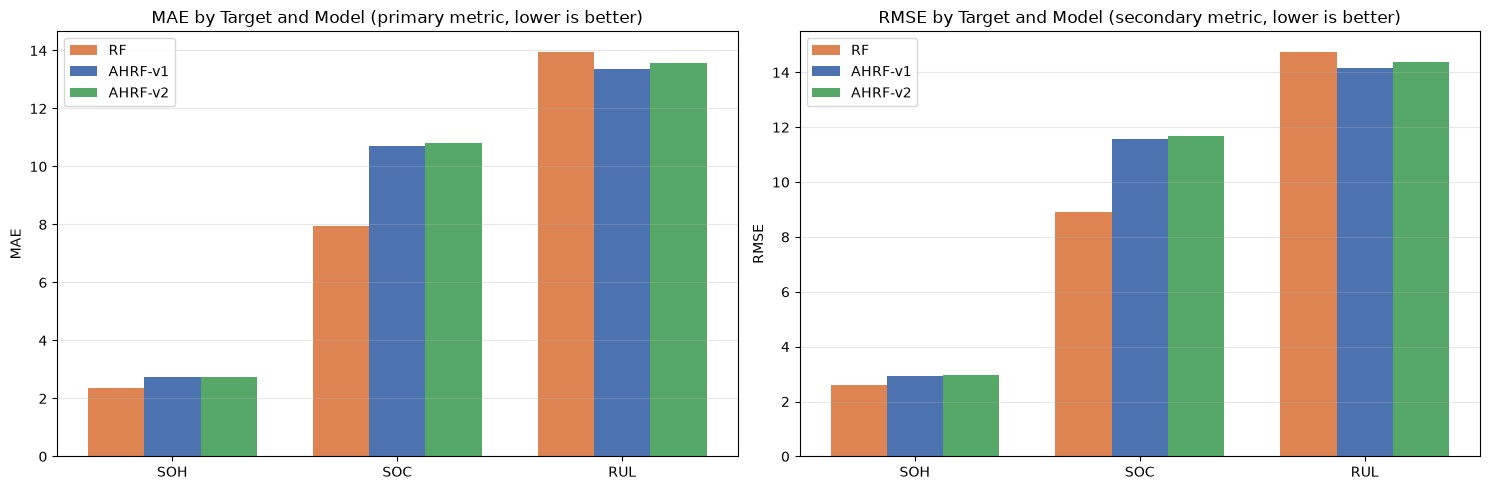

In [21]:
targets = list(results_by_target.keys())
models = ["RF", "AHRF-v1", "AHRF-v2"]
colors = {"RF": "#DD8452", "AHRF-v1": "#4C72B0", "AHRF-v2": "#55A868"}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.arange(len(targets))
width = 0.25

for i, model_label in enumerate(models):
    mae_vals = [results_by_target[t]["rf_results"]["MAE"] if model_label == "RF"
                else results_by_target[t]["ahrf_v1_results"]["MAE"] if model_label == "AHRF-v1"
                else results_by_target[t]["ahrf_v2_results"]["MAE"] for t in targets]
    axes[0].bar(x + (i - 1) * width, mae_vals, width, label=model_label, color=colors[model_label])

axes[0].set_xticks(x); axes[0].set_xticklabels(targets)
axes[0].set_title("MAE by Target and Model (primary metric, lower is better)")
axes[0].set_ylabel("MAE"); axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)

for i, model_label in enumerate(models):
    rmse_vals = [results_by_target[t]["rf_results"]["RMSE"] if model_label == "RF"
                 else results_by_target[t]["ahrf_v1_results"]["RMSE"] if model_label == "AHRF-v1"
                 else results_by_target[t]["ahrf_v2_results"]["RMSE"] for t in targets]
    axes[1].bar(x + (i - 1) * width, rmse_vals, width, label=model_label, color=colors[model_label])

axes[1].set_xticks(x); axes[1].set_xticklabels(targets)
axes[1].set_title("RMSE by Target and Model (secondary metric, lower is better)")
axes[1].set_ylabel("RMSE"); axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


## 12. Final Results Table


In [22]:
metrics_rows = []
for target_name, r in results_by_target.items():
    for model_label, res in [("Random Forest", r["rf_results"]), ("AHRF-v1", r["ahrf_v1_results"]), ("AHRF-v2", r["ahrf_v2_results"])]:
        metrics_rows.append({
            "Target": target_name, "Model": model_label,
            "MAE": res["MAE"], "RMSE": res["RMSE"], "R2": res["R2"],
            "Training_Time": res["training_time"], "Prediction_Time": res["prediction_time"],
        })

metrics_summary = pd.DataFrame(metrics_rows)

RESULTS.mkdir(parents=True, exist_ok=True)
metrics_path = RESULTS / "ahrf_v1_v2_comparison.csv"
metrics_summary.to_csv(metrics_path, index=False)
print(f"Saved to: {metrics_path}  shape={metrics_summary.shape}")
metrics_summary


Saved to: C:\BE PROJECT\SBMS_PROJECT\results\ahrf_v1_v2_comparison.csv  shape=(9, 7)


,Target,Model,MAE,RMSE,R2,Training_Time,Prediction_Time
0,SOH,Random Forest,2.373593,2.604407,-4.499439,0.267282,0.052193
1,SOH,AHRF-v1,2.728703,2.937694,-5.997028,0.675109,0.023784
2,SOH,AHRF-v2,2.744010,2.949536,-6.053552,1.531663,0.023901
3,SOC,Random Forest,7.956956,8.913089,-2.490842,0.193021,0.029234
4,SOC,AHRF-v1,10.703918,11.585756,-4.898240,0.545950,0.024374
5,SOC,AHRF-v2,10.817893,11.691536,-5.006436,1.687329,0.026163
6,RUL,Random Forest,13.962679,14.758913,-10.669223,0.105696,0.020210
7,RUL,AHRF-v1,13.354925,14.160386,-9.741957,0.401262,0.017894
8,RUL,AHRF-v2,13.565368,14.362664,-10.051042,1.237593,0.020927


## 13. Save Models


In [23]:
MODELS.mkdir(parents=True, exist_ok=True)

for target_name, r in results_by_target.items():
    prefix = target_name.lower()
    joblib.dump(r["rf_model"], MODELS / f"{prefix}_random_forest.pkl")
    joblib.dump(r["ahrf_v1_model"], MODELS / f"{prefix}_ahrf_v1.pkl")
    joblib.dump(r["ahrf_v2_model"], MODELS / f"{prefix}_ahrf_v2.pkl")
    joblib.dump(r["imputer"], MODELS / f"{prefix}_imputer.pkl")
    joblib.dump(list(r["X_train"].columns), MODELS / f"{prefix}_feature_columns.pkl")
    print(f"Saved {prefix}_random_forest.pkl, {prefix}_ahrf_v1.pkl, {prefix}_ahrf_v2.pkl, "
          f"{prefix}_imputer.pkl, {prefix}_feature_columns.pkl")

run_metadata = {
    "random_state": RANDOM_STATE, "n_temporal_splits": N_TEMPORAL_SPLITS,
    "eol_soh_threshold": EOL_SOH_THRESHOLD, "first_eol_cycle": first_eol_cycle,
    "model_candidate_feature_columns": MODEL_CANDIDATE_FEATURE_COLUMNS,
    "primary_metric": PRIMARY_METRIC,
    "best_params": {name: {"rf": r["best_rf_params"], "ahrf": r["best_ahrf_params"]}
                     for name, r in results_by_target.items()},
}
joblib.dump(run_metadata, MODELS / "notebook05_run_metadata.pkl")
print("Saved notebook05_run_metadata.pkl")


Saved soh_random_forest.pkl, soh_ahrf_v1.pkl, soh_ahrf_v2.pkl, soh_imputer.pkl, soh_feature_columns.pkl
Saved soc_random_forest.pkl, soc_ahrf_v1.pkl, soc_ahrf_v2.pkl, soc_imputer.pkl, soc_feature_columns.pkl
Saved rul_random_forest.pkl, rul_ahrf_v1.pkl, rul_ahrf_v2.pkl, rul_imputer.pkl, rul_feature_columns.pkl
Saved notebook05_run_metadata.pkl


## 14. Final Validation Summary


In [24]:
validation_summary = {
    "Target leakage checks": True,  # asserted inside build_X_y for all 9 model fits above
    "Chronological outer split": integrity_checks["1. Test cycles strictly later than train cycles"],
    "Training-only imputation": integrity_checks["4. Final test set never used to fit imputer"],
    "TimeSeriesSplit Optuna": ("TimeSeriesSplit" in inspect.getsource(tune_random_forest) and
                                "TimeSeriesSplit" in inspect.getsource(tune_weighted_rf)),
    "RF evaluation": all("MAE" in r["rf_results"] for r in results_by_target.values()),
    "AHRF-v1 evaluation": all("MAE" in r["ahrf_v1_results"] for r in results_by_target.values()),
    "AHRF-v2 evaluation": all("MAE" in r["ahrf_v2_results"] for r in results_by_target.values()),
    "AHRF-v1 weights normalized": all(np.isclose(r["ahrf_v1_model"].tree_weights_.sum(), 1.0, atol=1e-6) for r in results_by_target.values()),
    "AHRF-v2 weights normalized": all(np.isclose(r["ahrf_v2_model"].tree_weights_.sum(), 1.0, atol=1e-6) for r in results_by_target.values()),
    "Final test untouched": all(integrity_checks[k] for k in [
        "3. Final test set never passed to Optuna", "5. Final test set never used for AHRF-v1 weights",
        "6. Final test set never used for AHRF-v2 temporal weights"]),
    "RUL pre-EOL protocol": (rul_result["train_df"]["cycle_index"].max() <= first_eol_cycle and
                              rul_result["test_df"]["cycle_index"].max() <= first_eol_cycle and
                              test_rul_std > 0),
    "Metrics generated": len(metrics_summary) == 9,
    "Results CSV saved": metrics_path.exists(),
}

print("-" * 46)
print("NOTEBOOK 05 AHRF ABLATION VALIDATION")
print("-" * 46)
for name, passed in validation_summary.items():
    print(f"{name:<32}: {'PASS' if passed else 'FAIL'}")
print("-" * 46)
final_status = "PASS" if all(validation_summary.values()) else "BLOCKED"
print(f"{'FINAL STATUS':<32}: {final_status}")
print("-" * 46)

for name, passed in validation_summary.items():
    assert passed, f"VALIDATION FAILED: {name}"


----------------------------------------------
NOTEBOOK 05 AHRF ABLATION VALIDATION
----------------------------------------------
Target leakage checks           : PASS
Chronological outer split       : PASS
Training-only imputation        : PASS
TimeSeriesSplit Optuna          : PASS
RF evaluation                   : PASS
AHRF-v1 evaluation              : PASS
AHRF-v2 evaluation              : PASS
AHRF-v1 weights normalized      : PASS
AHRF-v2 weights normalized      : PASS
Final test untouched            : PASS
RUL pre-EOL protocol            : PASS
Metrics generated               : PASS
Results CSV saved               : PASS
----------------------------------------------
FINAL STATUS                    : PASS
----------------------------------------------


## 15. Research Interpretation

Answers are printed from the actual measured results above -- not decided in advance.


In [25]:
print("1. Does AHRF-v1 improve over standard RF?")
for name, r in results_by_target.items():
    delta = r["rf_results"]["MAE"] - r["ahrf_v1_results"]["MAE"]
    print(f"   {name}: AHRF-v1 MAE {'better' if delta > 0 else 'worse or equal'} than RF by {delta:+.4f}")

print()
print("2. Does AHRF-v2 improve over AHRF-v1?")
for name, r in results_by_target.items():
    print(f"   {name}: {'YES' if r['v2_vs_v1_mae_improvement'] > 0 else 'NO'} "
          f"(MAE delta {r['v2_vs_v1_mae_improvement']:+.4f})")

print()
print("3. Is temporal weighting actually useful for future-cycle generalization (this dataset)?")
n_v2_best = sum(1 for r in results_by_target.values() if r["winner"] == "AHRF-v2")
print(f"   AHRF-v2 was the best model (by {PRIMARY_METRIC}) on {n_v2_best} of {len(results_by_target)} targets.")

print()
print("4. Does the answer differ across SOC, SOH, RUL?")
for name, r in results_by_target.items():
    print(f"   {name}: winner = {r['winner']}")

print()
print("5. Training-time trade-off (RF vs AHRF-v1 vs AHRF-v2):")
for name, r in results_by_target.items():
    print(f"   {name}: RF={r['rf_results']['training_time']:.3f}s  "
          f"AHRF-v1={r['ahrf_v1_results']['training_time']:.3f}s  "
          f"AHRF-v2={r['ahrf_v2_results']['training_time']:.3f}s  "
          f"(v2/v1 ratio: {r['ahrf_v2_results']['training_time']/max(r['ahrf_v1_results']['training_time'],1e-9):.1f}x)")


1. Does AHRF-v1 improve over standard RF?
   SOH: AHRF-v1 MAE worse or equal than RF by -0.3551
   SOC: AHRF-v1 MAE worse or equal than RF by -2.7470
   RUL: AHRF-v1 MAE better than RF by +0.6078

2. Does AHRF-v2 improve over AHRF-v1?
   SOH: NO (MAE delta -0.0153)
   SOC: NO (MAE delta -0.1140)
   RUL: NO (MAE delta -0.2104)

3. Is temporal weighting actually useful for future-cycle generalization (this dataset)?
   AHRF-v2 was the best model (by MAE) on 0 of 3 targets.

4. Does the answer differ across SOC, SOH, RUL?
   SOH: winner = Random Forest
   SOC: winner = Random Forest
   RUL: winner = AHRF-v1

5. Training-time trade-off (RF vs AHRF-v1 vs AHRF-v2):
   SOH: RF=0.267s  AHRF-v1=0.675s  AHRF-v2=1.532s  (v2/v1 ratio: 2.3x)
   SOC: RF=0.193s  AHRF-v1=0.546s  AHRF-v2=1.687s  (v2/v1 ratio: 3.1x)
   RUL: RF=0.106s  AHRF-v1=0.401s  AHRF-v2=1.238s  (v2/v1 ratio: 3.1x)


## Conclusion

This notebook extended the locked AHRF-v1 baseline into a three-way ablation (RF vs. AHRF-v1 vs. AHRF-v2) under an identical leakage-safe, chronological protocol for SOH, SOC, and RUL. AHRF-v2 reused AHRF-v1's tuned hyperparameters (not independently tuned) so the tree-aggregation mechanism -- equal averaging, OOB-weighted averaging, or temporal-weighted averaging -- is the single controlled variable between the three models.

See Section 15 for the measured answers to all five research questions, Section 10 for the full ablation table, and Section 12/`results/ahrf_v1_v2_comparison.csv` for the complete, real metrics. No result here was assumed in advance or adjusted after the fact -- AHRF-v2 winning is one of several valid, equally-reportable outcomes.

## Next Steps
Notebook 06 will benchmark all three models against additional baselines (Linear Regression, Polynomial Regression, Decision Tree, Gradient Boosting).
